<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/11wk-2.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-yv6z57PIj-_9K12H8Jpy5p&si=_VnKtlZVlJL-Sxbj>}}

# 2. Imports

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (4.5, 3.0)

# 3. CNN (미리보기)

## A. 데이터 알아보기

`-` CNN: 이미지분석에 특화된 네트워크

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)
train_dataset = torch.utils.data.Subset(train_dataset, range(5000))
test_dataset = torch.utils.data.Subset(test_dataset, range(1000))
to_tensor = torchvision.transforms.ToTensor()
X = torch.stack([to_tensor(img) for img, lbl in train_dataset])
y = torch.tensor([lbl for img, lbl in train_dataset])
XX = torch.stack([to_tensor(img) for img, lbl in test_dataset])
yy = torch.tensor([lbl for img, lbl in test_dataset])

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


`-` 데이터를 간단히 살펴보자.

In [7]:
print(X.shape,y.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000])


- train data
- X: 이미지는 5000장, 흑백이미지, 크기는 (28,28)
- y: 이미지의 라벨을 정리한 length 5000의 vector. 카테고리는 총 10개 (원핫인코딩x)

In [8]:
print(XX.shape,yy.shape)

torch.Size([1000, 1, 28, 28]) torch.Size([1000])


- train data
- XX: 이미지는 1000장, 흑백이미지, 크기는 (28,28)
- yy: 이미지의 라벨을 정리한 length 5000의 vector. 카테고리는 총 10개 (원핫인코딩x)

`-` 이미지가 어떻게 생겼는지 알아보자.

In [147]:
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

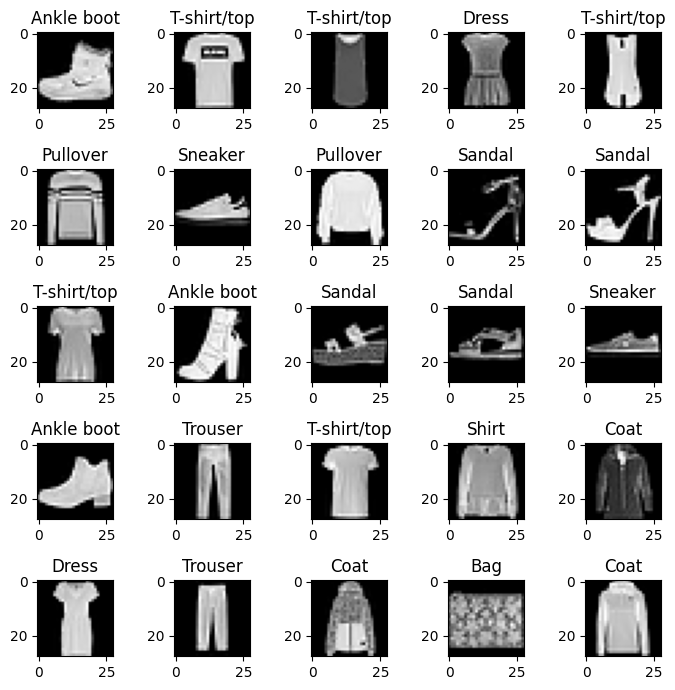

In [156]:
fig,ax = plt.subplots(5,5,figsize=(7,7))
for i in range(5):
    for j in range(5):
        ax[i][j].imshow(X[i*5+j].reshape(28,28),cmap="gray")
        ax[i][j].set_title(fashion_mnist_labels[y[i*5+j].item()]);
fig.tight_layout()

## B. Flatten

`-` 좋은테크닉

원래 $X$를 바로 학습할수 없어서 reshape을 해야함.

In [163]:
X.reshape(5000,784)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

그런데 이걸해주는 함수가 이미 구현되어 있음

In [164]:
flatten = torch.nn.Flatten()

In [166]:
flatten(X).shape

torch.Size([5000, 784])

## C. 최초적합하기

`-` 나이브한 최초적합

In [199]:
torch.manual_seed(0)
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,10),
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [205]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9422)

In [207]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8370)

- 썩 만족스러운건 아니다..

## D. 성능을 올리기 위한 노력들

`-` 혹시 오버피팅인가? 표현력을 줄여보자.

In [235]:
torch.manual_seed(0)
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,16),
    torch.nn.ReLU(),
    torch.nn.Linear(16,10),
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [236]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9078)

In [237]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8290)

- 표현력을 줄이니까.. net가 점점 멍청해지는 느낌임

`-` 아예 오버피팅을 감수하고 표현력을 올려보자.

In [252]:
torch.manual_seed(0)
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,10),
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [253]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9998, device='cuda:0')

In [254]:
net.to("cpu")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=10, bias=True)
)

In [255]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8530)

- 일단 85%까지왔음

`-` 아예 오버피팅을 감수하고 표현력을 올려보자 + 드랍아웃을 쓴다면? (오버피팅이 잡힘)

In [343]:
torch.manual_seed(0)
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,512),
    torch.nn.Dropout(0.9),
    torch.nn.ReLU(),
    torch.nn.Linear(512,10),
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [344]:
net.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): Dropout(p=0.9, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=10, bias=True)
)

In [345]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9508, device='cuda:0')

In [346]:
net.to("cpu")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): Dropout(p=0.9, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=10, bias=True)
)

In [347]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8600)

`-` 레이어를 더 쌓아볼까??

In [322]:
torch.manual_seed(0)
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,512),
    torch.nn.Dropout(0.9),
    torch.nn.ReLU(),
    torch.nn.Linear(512,256),
    torch.nn.ReLU(),
    torch.nn.Linear(256,256),
    torch.nn.ReLU(),
    torch.nn.Linear(256,256),
    torch.nn.ReLU(),
    torch.nn.Linear(256,10),
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(2000):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [323]:
net.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): Dropout(p=0.9, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=256, bias=True)
  (9): ReLU()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [324]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9858, device='cuda:0')

In [325]:
net.to("cpu")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): Dropout(p=0.9, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=256, bias=True)
  (9): ReLU()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [327]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8530)

`-` 아까의 성공모델을 변형

In [376]:
torch.manual_seed(0)
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,4096),
    torch.nn.Dropout(0.9),
    torch.nn.ReLU(),
    torch.nn.Linear(4096,10),
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [377]:
net.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=4096, bias=True)
  (2): Dropout(p=0.9, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=4096, out_features=10, bias=True)
)

In [378]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9894, device='cuda:0')

In [379]:
net.to("cpu")
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8660)

- 통곡의벽 86.60%

## E. CNN  

`-` 더 올려보겠습니다.

In [393]:
torch.manual_seed(0)
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Conv2d(1,16,2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2),
    torch.nn.Flatten(),
    torch.nn.Linear(2704,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [394]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9666, device='cuda:0')

In [395]:
net.to("cpu")
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8710)

- 시작하자마자 87.10%...

In [399]:
torch.manual_seed(0)
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Conv2d(1,32,2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(3),
    torch.nn.Flatten(),
    torch.nn.Linear(2592,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(500):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [400]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9632, device='cuda:0')

In [401]:
net.to("cpu")
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8750)

`-` 성능도 좋은데.. 파라메터가 적음

In [519]:
net1 = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,4096),
    torch.nn.ReLU(),
    torch.nn.Linear(4096,10),
)

In [522]:
lst1 = list(net1.parameters())
for l in lst1:
    print(l.shape)

torch.Size([4096, 784])
torch.Size([4096])
torch.Size([10, 4096])
torch.Size([10])


In [523]:
784*4096 + 4096  +  4096*10 + 10

3256330

In [525]:
net2 = torch.nn.Sequential(
    torch.nn.Conv2d(1,32,2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(3),
    torch.nn.Flatten(),
    torch.nn.Linear(2592,10)
)

In [528]:
lst2 = list(net2.parameters())
for l in lst2:
    print(l.shape)

torch.Size([32, 1, 2, 2])
torch.Size([32])
torch.Size([10, 2592])
torch.Size([10])


In [529]:
32*1*2*2 + 32 + 10*2592 + 10

26090

In [530]:
(32*1*2*2 + 32 + 10*2592 + 10 ) / (784*4096 + 4096  +  4096*10 + 10)

0.008012087227031658

`-` 참고자료(시험X): <https://brunch.co.kr/@hvnpoet/109>